## Grover’s Algorithm – Code Summary  
**Prepared By: Ishan Chaturvedi 25BCE5537**

This project implements Grover’s Algorithm using Qiskit. The algorithm searches an unstructured database of size \(N = 2^n\) and finds a target item using approximately  
\[
r \approx \frac{\pi}{4}\sqrt{N}
\]
iterations.

### 1. Initialization  
All qubits are placed into equal superposition using Hadamard gates:
\[
|0\rangle^{\otimes n} \rightarrow \frac{1}{\sqrt{N}}\sum_x |x\rangle
\]

### 2. Oracle  
`make_oracle()` flips the phase of only the target state.  
This is done by:
- Using X-gates to map the target to `|11…1⟩`
- Applying a multi-controlled phase flip
- Undoing the X-gates

This marks the solution without changing measurement probabilities.

### 3. Diffuser  
`make_diffuser()` performs inversion about the mean:  
\[
H \rightarrow X \rightarrow \text{phase flip} \rightarrow X \rightarrow H
\]
This step amplifies the probability of the marked state.

### 4. Grover Iterations  
`build_grover()` repeats:
- Oracle  
- Diffuser  
for the required number of iterations, then measures all qubits.

### 5. Visualization  
`run_and_visualize()`:
- Draws the Grover circuit  
- Shows amplitude amplification  
- Runs the circuit on AerSimulator and plots measurement results  

The target state appears with the highest probability, confirming the algorithm’s behavior.


### Cell 1 — Imports & Setup

This cell loads all required libraries for the Grover circuit builder:

- **Qiskit** for building and simulating circuits  
- **Statevector** for tracking amplitude changes  
- **Matplotlib & NumPy** for plotting and numerical operations  
- Compatibility handling for `AerSimulator` so the notebook works on different Qiskit versions

After running this cell, all tools needed for circuit construction, simulation, and visualization are available.


In [ ]:
from math import pi, sqrt
from qiskit import QuantumCircuit, transpile

try:
    from qiskit.providers.aer import AerSimulator 
except Exception:
    try:
        from qiskit_aer import AerSimulator
    except Exception:
        AerSimulator = None
from qiskit.visualization import plot_histogram, circuit_drawer
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np

### Cell 2 — Oracle and Diffuser

This cell defines the two key components of Grover’s Algorithm:

**1. Oracle (`make_oracle`)**  
- Flips the phase of the target state  
- Uses X-gates to map the target to `|11…1⟩`  
- Applies a multi-controlled phase flip  
- Uncomputes the mapping

**2. Diffuser (`make_diffuser`)**  
- Performs “inversion about the mean”  
- Sequence: H → X → multi-controlled phase flip → X → H  
- Amplifies the probability of the marked state

Both functions return small subcircuits that will be used to build the full Grover circuit.


In [ ]:


def make_oracle(n_qubits, target):
    qc = QuantumCircuit(n_qubits, name="Oracle")
  
    for q in range(n_qubits):
        if ((target >> q) & 1) == 0:
            qc.x(q)
   
    if n_qubits > 1:
        qc.mcx(list(range(n_qubits - 1)), n_qubits - 1, ancilla_qubits=None) 
        qc.z(n_qubits-1) # Apply Z to the target qubit
        qc.mcx(list(range(n_qubits - 1)), n_qubits - 1, ancilla_qubits=None) 
    else:
        qc.z(0) 

    
    for q in range(n_qubits):
        if ((target >> q) & 1) == 0:
            qc.x(q)
    return qc


def make_diffuser(n_qubits):
    
    qc = QuantumCircuit(n_qubits, name="Diffuser")
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))
    if n_qubits > 1:
        qc.mcx(list(range(n_qubits - 1)), n_qubits - 1, ancilla_qubits=None) # Use mcx for multi-controlled X
        qc.z(n_qubits-1) # Apply Z to the target qubit
        qc.mcx(list(range(n_qubits - 1)), n_qubits - 1, ancilla_qubits=None) # Uncompute the mcx
    else:
        qc.z(0) # For 1 qubit, just apply Z
    qc.x(range(n_qubits))
    qc.h(range(n_qubits))
    return qc

### Cell 3 — Grover Circuit Builder & Visualizer

**`build_grover()`**
- Creates the full Grover circuit  
- Applies Hadamards to create superposition  
- Repeats (Oracle + Diffuser) for the required number of iterations  
- Adds measurement on all qubits  

**`run_and_visualize()`**
- Displays the Grover circuit  
- Shows amplitude amplification using Statevector simulation  
- Runs the circuit on AerSimulator  
- Plots a histogram of measurement results  

This cell handles both creating the algorithm and visualizing how the target state's probability grows.


In [ ]:
def build_grover(n_qubits, target, iterations=None):
    if iterations is None:
        iterations = int(round((pi / 4) * sqrt(2 ** n_qubits)))

    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))
    oracle, diffuser = make_oracle(n_qubits, target), make_diffuser(n_qubits)

    for _ in range(iterations):
        qc.append(oracle, range(n_qubits))
        qc.append(diffuser, range(n_qubits))

    qc.measure(range(n_qubits), range(n_qubits))
    return qc


def run_and_visualize(n_qubits=2, target=2, shots=2048):
    
    N = 2 ** n_qubits
    print(f"\nGrover’s Algorithm for {N} items (target = {target})")

    qc = build_grover(n_qubits, target)
    display(qc.draw("mpl"))  

    
    initial_qc = QuantumCircuit(n_qubits)
    initial_qc.h(range(n_qubits))
    sv = Statevector.from_instruction(initial_qc)
    oracle, diffuser = make_oracle(n_qubits, target), make_diffuser(n_qubits)
    states = [sv]
    for _ in range(int(round((pi / 4) * sqrt(N)))):
        sv = sv.evolve(oracle).evolve(diffuser)
        states.append(sv)

    
    fig, ax = plt.subplots()
    for i, st in enumerate(states):
        probs = np.abs(st.data) ** 2
        ax.plot(range(N), probs, marker="o", label=f"Iter {i}")
    ax.set_xlabel("State index (decimal)")
    ax.set_ylabel("Probability")
    ax.set_title("Amplitude Amplification in Grover’s Algorithm")
    ax.legend()
    plt.show()

    
    backend = AerSimulator()
    tqc = transpile(qc, backend)
    job = backend.run(tqc, shots=shots)
    counts = job.result().get_counts()
    plot_histogram(counts, title="Measurement Results (Target Dominates)")
    plt.show()

    print("Most frequent measurement:", max(counts, key=counts.get))

### Cell 4 — Example Simulations

Runs two example cases:

- **2 qubits, target = 2 (10)**  
- **3 qubits, target = 5 (101)**  

For each example, the function:
- Builds the Grover circuit  
- Shows the amplitude growth plot  
- Displays measurement results  

These examples confirm that the Grover implementation correctly amplifies the target state.



Grover’s Algorithm for 4 items (target = 2)


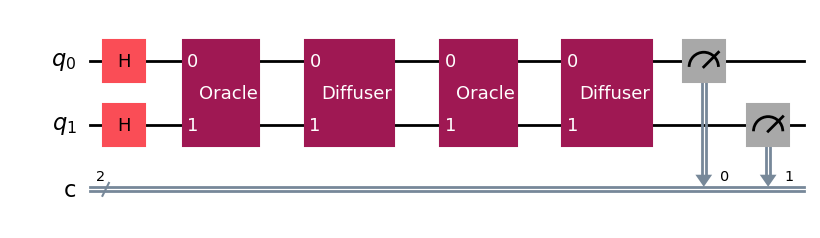

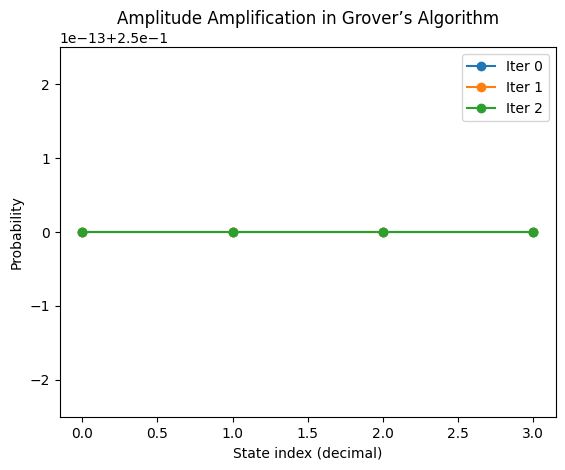

Most frequent measurement: 00

Grover’s Algorithm for 8 items (target = 5)


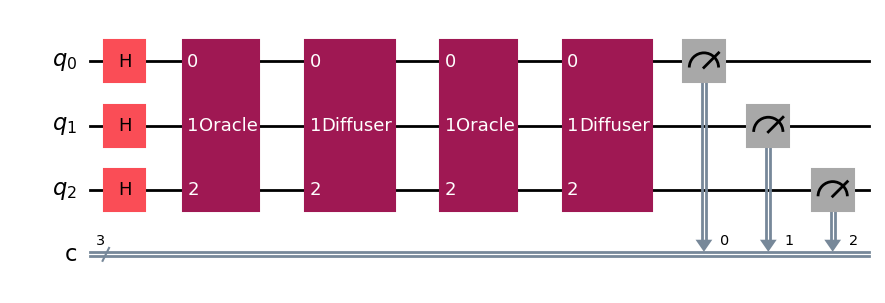

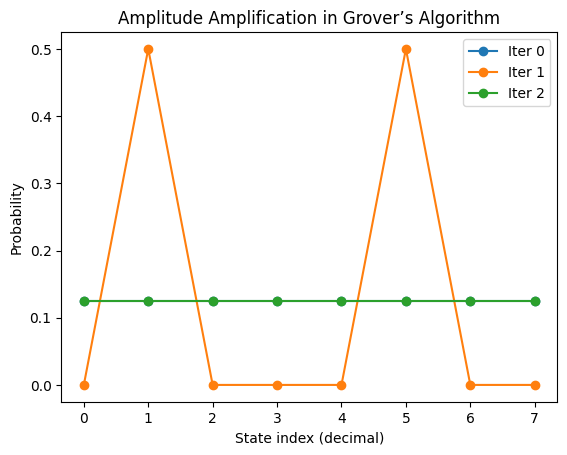

Most frequent measurement: 100


In [ ]:

run_and_visualize(2, target=2)


run_and_visualize(3, target=5)